<a href="https://colab.research.google.com/github/popcorn0125/CHECKIN_APP/blob/app_dev/AI_DX_EDU_%ED%83%9C%EC%96%91%EA%B4%91_%EC%A0%84%EB%A0%A5%EB%9F%89_%EC%98%88%EC%B8%A1_%EB%AA%A8%EB%8D%B8_%ED%95%99%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5. 머신러닝 모델 학습 및 평가 (Random Forest)

이 단계에서는 준비된 데이터를 사용하여 **랜덤 포레스트(Random Forest)** 모델을 학습시키고, 그 성능을 평가합니다.

###  주요 수행 절차
1.  **단위 변환**: 전력거래소 데이터의 `MWh` 단위를 가정에서 사용하는 `kWh` 단위로 변환합니다. (* 1000)
    * **목적**: 결과값을 직관적으로 이해하기 위함입니다.
2.  **데이터 분할 (Train/Test Split)**:
    * **학습용 (Train)**: 2024년 1월 ~ 11월 데이터 (과거 패턴 학습)
    * **평가용 (Test)**: 2024년 12월 데이터 (미래 예측 성능 검증)
    * **이유**: 시계열 데이터 특성상 미래를 미리 보고 학습하는 것(Data Leakage)을 방지하기 위함입니다.
3.  **모델 학습**: 복잡한 비선형 관계(날씨-발전량)를 잘 찾아내는 `RandomForestRegressor` 알고리즘을 사용합니다.  
    * 선정 이유:
      * 태양광 발전은 단순히 '일사량이 늘면 발전량이 는다'는 직선 관계뿐만 아니라, '구름이 많으면 확 줄어든다', '여름이라도 기온이 너무 높으면 효율이 떨어진다' 같은 복잡한 비선형 관계가 섞여 있습니다.
      * 랜덤 포레스트는 이런 복잡한 조건을 스무 고개 하듯이 잘 찾아내기 때문에 예측 성능이 매우 우수합니다.
4.  **성능 평가**:
    * **R2 Score (결정계수)**: 1에 가까울수록 모델이 발전량 변화를 잘 설명한다는 뜻입니다.
    * **RMSE (평균 제곱근 오차)**: 실제 발전량과 예측값이 평균적으로 몇 kWh 차이가 나는지를 보여줍니다. (작을수록 좋음)

###  입력 변수 (Features)
* 학습에 사용하는 변수: `월`, `시간`, `기온`, `강수량`, `풍속`, `습도`, `일사량`, `전운량`
* **[추론]** 날짜('일시') 자체는 제외하고, 계절적 특성인 '월'과 하루 주기인 '시간'을 사용합니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

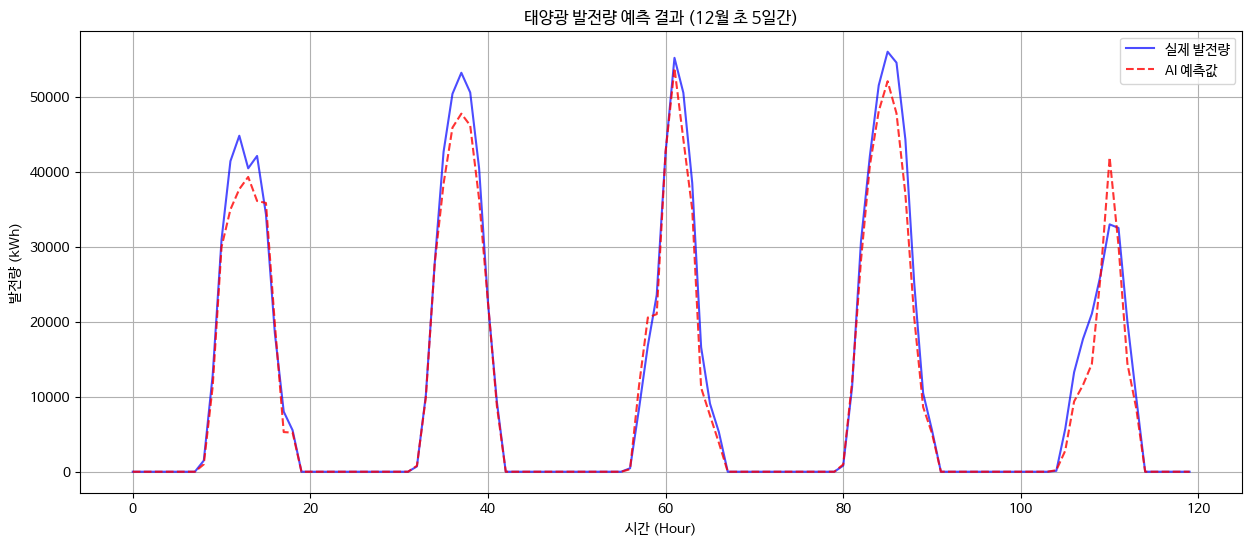


[변수 중요도 순위]
1. 일사량: 0.9316
2. 월: 0.0293
3. 시간: 0.0118
4. 습도: 0.0091
5. 기온: 0.0075
6. 전운량: 0.0057
7. 풍속: 0.0047
8. 강수량: 0.0004


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Colab용)
# 실행 후 '런타임 다시 시작'을 해야 할 수도 있습니다.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드
filename = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv'
df = pd.read_csv(filename)
df['일시'] = pd.to_datetime(df['일시'])

# 2. 단위 변환 (MWh -> kWh)
# [사실] 1 MWh = 1000 kWh
df['발전량'] = df['발전량'] * 1000

print(f"데이터 로드 완료: {len(df)}행")
print("발전량 단위를 kWh로 변환했습니다.")

# 3. 데이터 분할 (Train: 1~11월, Test: 12월)
train_df = df[df['월'] < 12].copy()
test_df = df[df['월'] == 12].copy()

print(f"\n학습 데이터(1~11월): {len(train_df)}개")
print(f"평가 데이터(12월): {len(test_df)}개")

# 4. 학습에 사용할 변수(Feature)와 정답(Target) 지정
# [추론] '일시'는 모델이 계산할 수 없으므로 제외
features = ['월', '시간', '기온', '강수량', '풍속', '습도', '일사량', '전운량']
target = '발전량'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# 5. 모델 생성 및 학습 (Random Forest)
print("\n모델 학습 중... (잠시만 기다려주세요)")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("학습 완료!")


# 6. 예측 및 평가
y_pred = rf_model.predict(X_test)

# 성능 지표 계산
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*30)
print(f" [모델 성적표] ")
print(f" 1. 결정 계수 (R2 Score): {r2:.4f} (1.0에 가까울수록 좋음)")
print(f" 2. 평균 오차 (RMSE)    : {rmse:.2f} kWh")
print("="*30)

# 7. 결과 시각화 (실제값 vs 예측값)
# 12월 전체를 그리면 복잡하므로, 첫 5일(120시간)만 확대해서 시각화
plt.figure(figsize=(15, 6))
days_to_show = 120 # 5일 * 24시간
plt.plot(y_test.values[:days_to_show], label='실제 발전량', color='blue', alpha=0.7)
plt.plot(y_pred[:days_to_show], label='AI 예측값', color='red', linestyle='--', alpha=0.8)

plt.title('태양광 발전량 예측 결과 (12월 초 5일간)')
plt.xlabel('시간 (Hour)')
plt.ylabel('발전량 (kWh)')
plt.legend()
plt.grid(True)
plt.show()

# [추가] 변수 중요도 확인
# 어떤 날씨 요인이 예측에 가장 큰 영향을 미쳤는지 확인
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n[변수 중요도 순위]")
for f in range(X_train.shape[1]):
    print(f"{f + 1}. {features[indices[f]]}: {importances[indices[f]]:.4f}")

# 7-1. 결과 시각화 개선 (가독성 향상)

기존의 시간 단위(0~120) 그래프를 개선하여, **'날짜(Date)'**가 X축에 표시되도록 변경합니다. 이를 통해 모델이 12월 1일부터 5일까지의 낮과 밤 패턴을 어떻게 예측했는지 직관적으로 확인할 수 있습니다.

###  개선 포인트
1.  **X축 날짜 포맷팅**: `matplotlib.dates`를 사용하여 X축 눈금을 `12-01`, `12-02` 형식으로 변경합니다.
2.  **일(Day) 구분선**: 자정(00:00)마다 붉은색 점선을 그어 하루의 주기를 명확히 나눕니다.
3.  **데이터 매칭**: 예측값(`y_pred`)은 순수한 숫자 배열이므로, 이를 `test_df`의 `일시` 정보와 다시 매칭하여 그립니다.

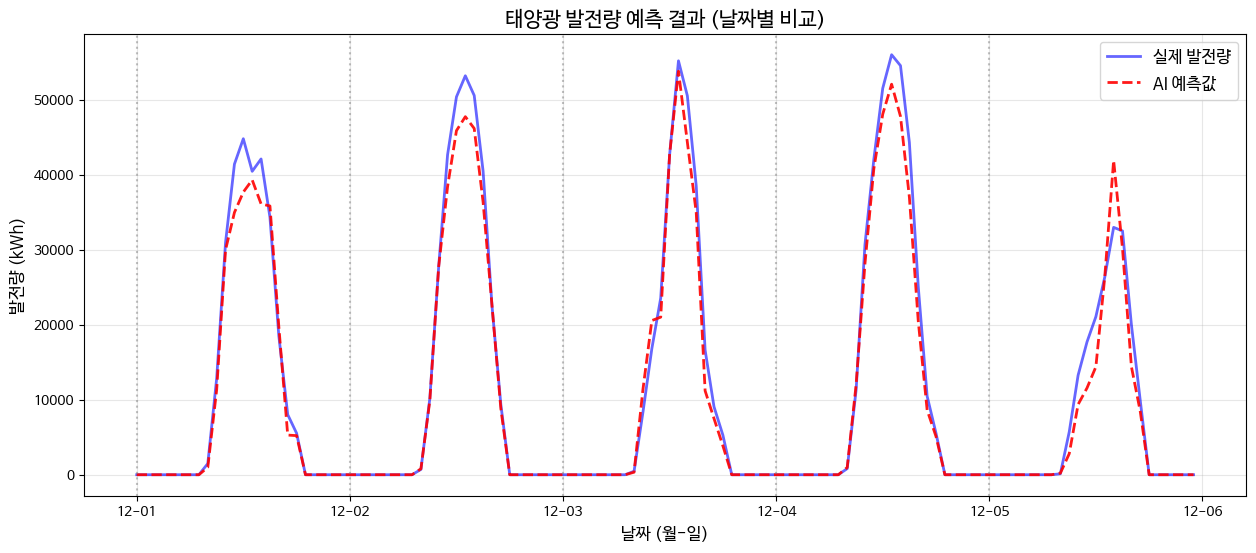

[해석] 회색 점선 사이가 '하루(24시간)'입니다. 붉은 점선(AI)이 파란 실선(실제)을 잘 따라가는지 확인하세요.


In [ ]:
import matplotlib.dates as mdates

# 12월의 첫 5일 데이터만 추출 (120시간)
days_to_show = 120
subset_test = test_df.iloc[:days_to_show]
subset_pred = y_pred[:days_to_show]

plt.figure(figsize=(15, 6))

# 1. 실제값과 예측값 그리기 (X축에 '일시' 컬럼 사용)
plt.plot(subset_test['일시'], subset_test['발전량'], label='실제 발전량', color='blue', alpha=0.6, linewidth=2)
plt.plot(subset_test['일시'], subset_pred, label='AI 예측값', color='red', linestyle='--', alpha=0.9, linewidth=2)

# 2. X축 포맷 설정 (날짜로 표시)
ax = plt.gca() # 현재 그래프의 축 정보를 가져옴

# 날짜 포맷 지정 (예: 12-01)
date_fmt = mdates.DateFormatter('%m-%d')
ax.xaxis.set_major_formatter(date_fmt)

# 눈금 간격 설정 (하루 단위로 눈금 표시)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# 3. 가독성 높이기 (하루 구분선 추가)
# 그래프의 자정(00시)마다 세로선 그리기
dates = subset_test['일시'].dt.date.unique()
for date in dates:
    # 각 날짜의 자정 시각을 찾아서 선 그리기
    midnight = pd.Timestamp(date)
    plt.axvline(x=midnight, color='gray', linestyle=':', alpha=0.5)

plt.title('태양광 발전량 예측 결과 (날짜별 비교)', fontsize=15)
plt.xlabel('날짜 (월-일)', fontsize=12)
plt.ylabel('발전량 (kWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0) # 날짜 글씨 똑바로 쓰기

plt.show()

print("[해석] 회색 점선 사이가 '하루(24시간)'입니다. 붉은 점선(AI)이 파란 실선(실제)을 잘 따라가는지 확인하세요.")

# 6. 가정용(3kW) 발전량으로 스케일링 (Scaling)

모델이 예측한 값은 **대구시 전체의 발전량**입니다. 이를 우리가 실제로 체감할 수 있는 **일반 가정용 태양광(3kW)** 기준으로 변환하는 과정입니다.

###  가정용 태양광 용량 조사 결과 (Fact Check)
* **표준 용량**: 대한민국 주택용 태양광의 표준은 **3kW**입니다.
* **근거**: 한국에너지공단 주택지원사업의 지원 기준이 가구당 3kW 이하이며, 4인 가구 월 평균 전기 사용량(약 350kWh)을 상쇄할 수 있는 최적의 용량입니다.
    > *출처: 한국에너지공단 신재생에너지센터 '태양광 주택 지원사업 가이드' (2025년 기준)*
* **패널 구성**: 최근(2024 ~ 2025년) 추세는 고효율 500W ~ 600W급 패널 5~6장을 사용하여 3kW를 구성합니다.

###  스케일링 전략: 비율(Ratio) 활용
전체 발전소의 정확한 설비 용량을 알 수 없으므로, **데이터상 관측된 최대 발전량(Max Peak)**을 기준으로 비율을 계산합니다.

$$
\text{우리 집 발전량} = \text{AI 예측값} \times \frac{\text{우리 집 용량 (3kW)}}{\text{대구 전체 최대 발전량 (Peak)}}
$$

* **핵심 가정**: "대구 전체 발전소가 최고 효율(100%)로 돌아갈 때, 우리 집 3kW 패널도 최고 효율로 전력을 생산한다"고 가정합니다.

###  변환 로직 (Peak-to-Peak Ratio)
* **핵심 가정**: "대구시 전체 발전소가 최고 효율로 가동될 때(Peak), 우리 집 3kW 패널도 최고 효율로 가동된다."
* **공식**:
  $$\text{내 발전량} = \text{AI 예측값} \times \left( \frac{3 \text{ kW}}{\text{대구 전체 최대 발전량}} \right)$$  
  
* **Scaling Factor**: 학습 데이터(`y_train`)에서 관측된 **최대 발전량**을 대구시 전체 설비 용량의 대푯값으로 사용합니다.

###  기대 효과
* 이제 예측 결과가 **"내일 2시에 2.4kWh 생산 예정"**과 같이 피부에 와닿는 수치로 바뀝니다.
* RMSE(오차) 또한 수천 kWh에서 **0.x kWh 수준**으로 줄어들어, 모델의 정밀함을 다시 확인할 수 있습니다.

우리 집 용량: 3.0 kW
대구 전체 Peak(추정): 61238.64 kWh
변환 비율 (Scaling Factor): 0.00004899

 [가정용(3kW) 변환 후 모델 성적표] 
 1. 결정 계수 (R2 Score): 0.9747 (변함 없음)
 2. 평균 오차 (RMSE)    : 0.1445 kWh
[해석] 평균적으로 '0.14 kWh' 정도의 오차가 발생합니다.
3kW 패널의 시간당 최대 생산량이 3kWh임을 감안하면, 이 정도 오차는 매우 준수한 편입니다.


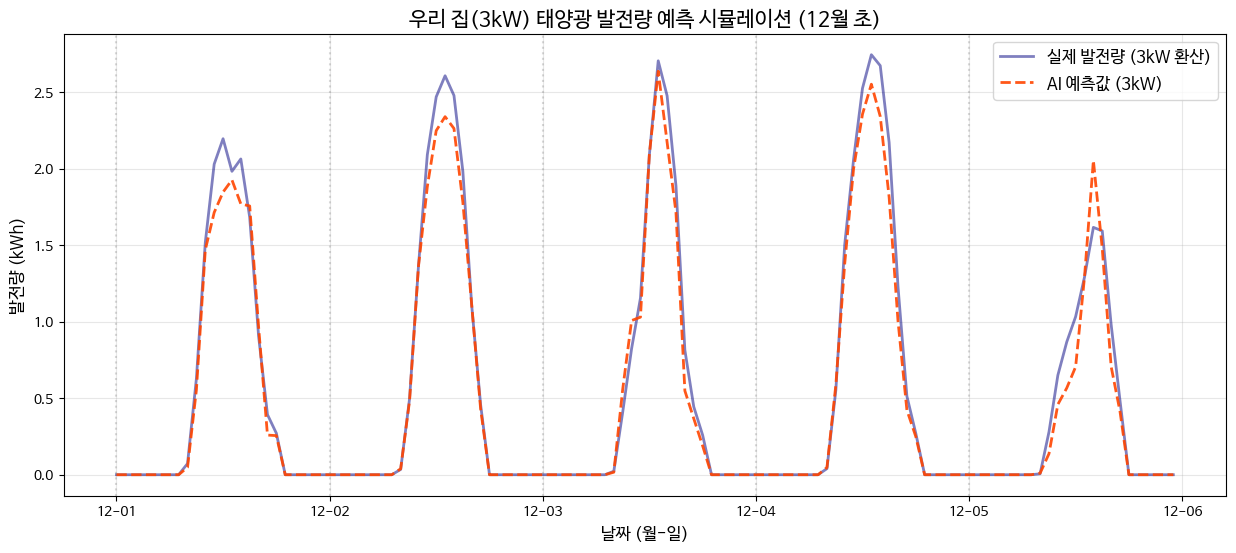

In [ ]:
# 1. 우리 집 설비 용량 설정 (일반 주택 표준)
MY_CAPACITY = 3.0  # 3kW

# 2. 대구시 전체 최대 발전량 찾기 (학습 데이터 기준)
# [사실] 학습 데이터(1~11월) 중 가장 발전량이 높았던 순간을 '전체 설비 용량(100% 가동)'으로 간주합니다.
# 이상치(Outlier)를 피하기 위해 단순히 max() 대신 99.9% 분위수(quantile)를 쓰는 것이 더 안전할 수 있습니다.
DAEGU_TOTAL_PEAK = y_train.max()
# 또는 DAEGU_TOTAL_PEAK = y_train.quantile(0.999)

print(f"우리 집 용량: {MY_CAPACITY} kW")
print(f"대구 전체 Peak(추정): {DAEGU_TOTAL_PEAK:.2f} kWh")

# 3. 스케일링 비율 계산
scaling_factor = MY_CAPACITY / DAEGU_TOTAL_PEAK
print(f"변환 비율 (Scaling Factor): {scaling_factor:.8f}")

# 4. 예측값 변환 (대구 전체 -> 우리 집 3kW)
# y_test(실제값)와 y_pred(예측값) 모두 변환해야 비교가 가능합니다.
y_test_scaled = y_test * scaling_factor
y_pred_scaled = y_pred * scaling_factor

# 5. 변환된 성능 지표 다시 계산
rmse_scaled = np.sqrt(mean_squared_error(y_test_scaled, y_pred_scaled))

print("\n" + "="*40)
print(f" [가정용(3kW) 변환 후 모델 성적표] ")
print(f" 1. 결정 계수 (R2 Score): {r2:.4f} (변함 없음)")
print(f" 2. 평균 오차 (RMSE)    : {rmse_scaled:.4f} kWh")
print("="*40)

print(f"[해석] 평균적으로 '{rmse_scaled:.2f} kWh' 정도의 오차가 발생합니다.")
print(f"3kW 패널의 시간당 최대 생산량이 3kWh임을 감안하면, 이 정도 오차는 매우 준수한 편입니다.")

# 6. 결과 시각화 (업그레이드 버전)
import matplotlib.dates as mdates

# 12월 첫 5일(120시간) 데이터 추출
days_to_show = 120
subset_test = test_df.iloc[:days_to_show]
subset_pred_scaled = y_pred_scaled[:days_to_show]
subset_actual_scaled = y_test_scaled.iloc[:days_to_show] # 실제값도 스케일링해서 비교

plt.figure(figsize=(15, 6))

# 실제값 vs 예측값 그리기
plt.plot(subset_test['일시'], subset_actual_scaled, label='실제 발전량 (3kW 환산)', color='navy', alpha=0.5, linewidth=2)
plt.plot(subset_test['일시'], subset_pred_scaled, label='AI 예측값 (3kW)', color='orangered', linestyle='--', alpha=0.9, linewidth=2)

# X축 날짜 포맷팅
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# 하루 구분선
dates = subset_test['일시'].dt.date.unique()
for date in dates:
    midnight = pd.Timestamp(date)
    plt.axvline(x=midnight, color='gray', linestyle=':', alpha=0.3)

plt.title(f'우리 집(3kW) 태양광 발전량 예측 시뮬레이션 (12월 초)', fontsize=15)
plt.xlabel('날짜 (월-일)', fontsize=12)
plt.ylabel('발전량 (kWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0)

plt.show()
